## FASE 3: Modelado de Tendencia mediante Regresión por Mínimos Cuadrados

En esta fase, transformamos los datos discretos del precio en una función continua $f(t)$ que represente la tendencia principal del mercado. Para ello, aplicamos el método de **Mínimos Cuadrados**.

**Fundamento Matemático:**
El objetivo es encontrar los coeficientes de un polinomio de grado $n$ que minimice la suma de los cuadrados de las diferencias (residuos) entre los precios reales ($y_i$) y los valores calculados por nuestra función ($f(t_i)$):

$$\min \sum_{i=0}^{m} [y_i - f(t_i)]^2$$

**Utilidad en el Proyecto:**
1. **Reducción de Ruido:** Filtramos las fluctuaciones aleatorias del mercado para identificar la dirección estructural del precio.
2. **Obtención de una Ecuación:** Generamos una expresión matemática analítica que nos permitirá realizar estimaciones fuera del rango de datos actual.
3. **Análisis de Aceleración:** Dependiendo del grado del polinomio (lineal o cuadrático), podremos determinar no solo la dirección, sino si el movimiento del precio se está acelerando o desacelerando.

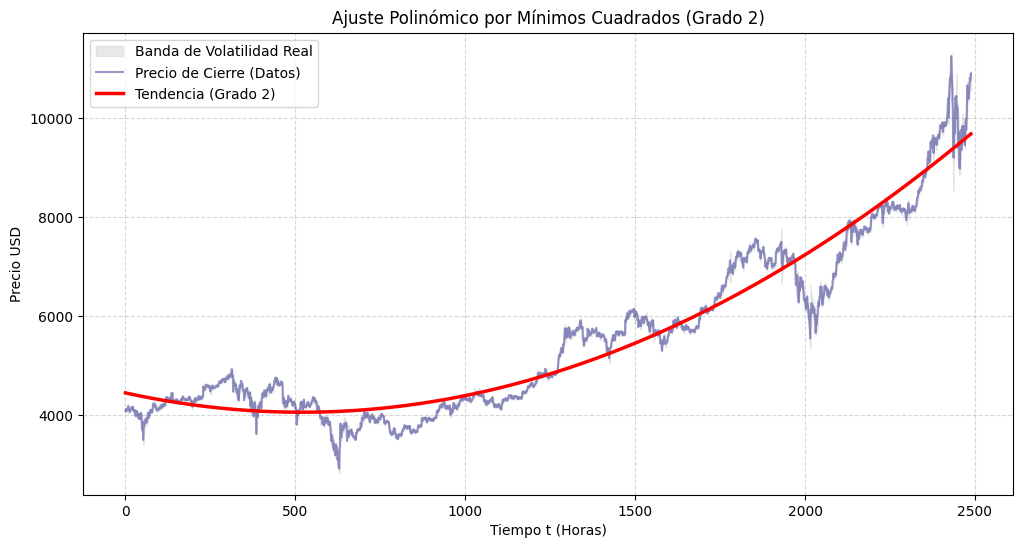

--- RESULTADOS DE LA REGRESIÓN ---
La función obtenida f(t) es:

         2
0.00145 x - 1.505 x + 4449

Esta ecuación representa el comportamiento promedio del activo en el intervalo.


In [156]:
#Modelado de Tendencia (Regresión)
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DEL MODELO ---
# Seleccione el grado del polinomio (1 para Lineal, 2 para Cuadrático):
grado_deseado = 2 # {type:"slider", min:1, max:2, step:1}

# --- 2. CÁLCULO DE MÍNIMOS CUADRADOS ---
# t es nuestra variable independiente y close_price la dependiente
t_valores = df_analisis['t'].values
y_valores = df_analisis['close_price'].values

# Obtenemos los coeficientes del polinomio (an, an-1, ..., a0)
coeficientes = np.polyfit(t_valores, y_valores, grado_deseado)

# Creamos la función matemática f(t) a partir de los coeficientes
modelo_tendencia = np.poly1d(coeficientes)

# Calculamos los valores de la tendencia para graficarlos
y_tendencia = modelo_tendencia(t_valores)

# --- 3. VISUALIZACIÓN TÉCNICA COMBINADA ---
plt.figure(figsize=(12, 6))

# Sombra de volatilidad (Fase 2)
plt.fill_between(t_valores, df_analisis['low_price'], df_analisis['high_price'],
                 color='lightgray', alpha=0.5, label='Banda de Volatilidad Real')

# Precio de cierre real
plt.plot(t_valores, y_valores, color='navy', alpha=0.4, label='Precio de Cierre (Datos)')

# Línea de Tendencia (Fase 3)
plt.plot(t_valores, y_tendencia, color='red', linewidth=2.5, label=f'Tendencia (Grado {grado_deseado})')

# Formato de la gráfica
plt.title(f'Ajuste Polinómico por Mínimos Cuadrados (Grado {grado_deseado})')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 4. EXPRESIÓN MATEMÁTICA RESULTANTE ---
print("--- RESULTADOS DE LA REGRESIÓN ---")
print(f"La función obtenida f(t) es:\n")
print(modelo_tendencia)
print("\nEsta ecuación representa el comportamiento promedio del activo en el intervalo.")